In [22]:
from model import *
import matplotlib.pyplot as plt
import skimage.io as io
from preprocess import Vocabulary
from config import csv_train_path, train_root_dir
import csv
import nltk
import pandas as pd

In [4]:
# Preprocess captions
# Make a list of all train captions
train_captions = []
with open(csv_train_path, newline='', encoding='utf-8') as csvfile:
    reader = csv.reader(csvfile)
    next(reader)  # Skip header
    for row in reader:
        train_captions.extend(row[1:6])
# Tokenize train captions
tokenized_captions = [nltk.word_tokenize(s.lower()) for s in train_captions]

# Make vocabulary out of train captions
miniCOCO_vocabulary = Vocabulary(freq_threshold=1)
miniCOCO_vocabulary.build_vocabulary(sentences_list=tokenized_captions)

Building vocabulary...
Vocabulary built with 924 words.


In [5]:
# Define model (hyper)parameters
feature_size = 50
embed_size = feature_size  # Because both words (tokens) and images are embedded to the same vector space
hidden_size = 10
vocab_size = 924
max_seq_length = 27
num_layers = 1

In [6]:
# Load saved models
decoder_path = f'trained_models/decoder.pth'
encoder_path = f'trained_models/encoder.pth'

encoder = EncoderCNN(feature_size=feature_size)
decoder = DecoderRNN(embed_size=50,
                    hidden_size=hidden_size,
                    vocab_size=vocab_size,
                    num_layers=num_layers,
                    max_seq_length=max_seq_length)

encoder.load_state_dict(torch.load(encoder_path))
decoder.load_state_dict(torch.load(decoder_path))

<All keys matched successfully>

In [7]:
# Set the model to evaluation mode
encoder.eval()
decoder.eval()

DecoderRNN(
  (embed): Embedding(924, 50)
  (lstm): LSTM(50, 10, batch_first=True)
  (linear): Linear(in_features=10, out_features=924, bias=True)
)

In [8]:
# Define image preprocessing pipeline
transform = transforms.Compose([
    transforms.Resize(256),  # Resize the image to 256x256
    transforms.CenterCrop(224),  # Crop the center 224x224
    transforms.ToTensor(),  # Convert PIL image to a PyTorch tensor
    transforms.Normalize(  # Normalize the tensor with the ImageNet mean and standard deviation
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [15]:
frame = pd.read_csv(csv_train_path)

In [25]:
def show_and_tell(img_name, encoder, decoder):
    # Image for evaluation
    img_path = train_root_dir + img_name
    img = Image.open(img_path)

    # Show image
    I = io.imread(img_path)
    plt.figure(figsize=(5, 5))
    plt.axis('off')
    plt.imshow(I)
    plt.show()

    # Forward pass
    input = transform(img).unsqueeze(0)  # Add batch dimension
    with torch.no_grad():
        features = encoder(input)

    outputs, word_ids = decoder.sample(features)
    print(f'{word_ids=}', '\n')
    caption = []
    for i in range(27):
        caption.append(miniCOCO_vocabulary.idx2word[word_ids[0, i].item()])
    print(caption)

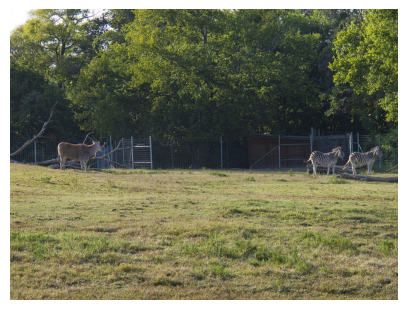

word_ids=tensor([[426,  60,   6, 505,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['match', ',', 'and', 'books', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


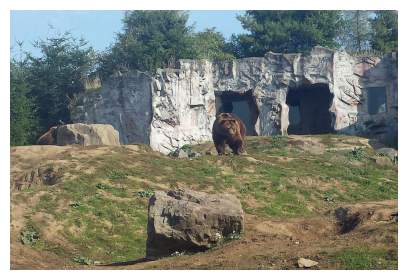

word_ids=tensor([[ 34,  23,  10, 119, 196,  35,  10, 166, 452, 172,  23,  10, 247,   2,
           2,   2,   2,   6, 173, 155,  23,  10, 119, 196,  35,  10, 166]]) 

['bear', 'on', 'a', 'white', 'photo', 'of', 'a', 'small', 'suitcase', 'sitting', 'on', 'a', 'skateboard', '<END>', '<END>', '<END>', '<END>', 'and', 'other', 'food', 'on', 'a', 'white', 'photo', 'of', 'a', 'small']


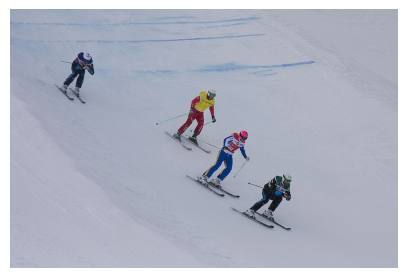

word_ids=tensor([[435, 150, 114, 115, 583, 775,   2,   2,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2, 895,   2,   2,   2]]) 

['looking', 'flat', 'homer', 'laughlin', 'followed', 'windows', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', 'mice', '<END>', '<END>', '<END>']


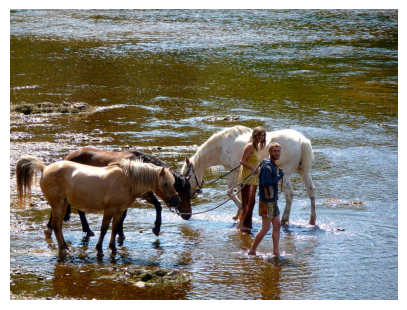

word_ids=tensor([[260, 539, 426, 260, 539,  19, 649,  92,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['boy', 'lined', 'match', 'boy', 'lined', 'direction', 'back', 'corner', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


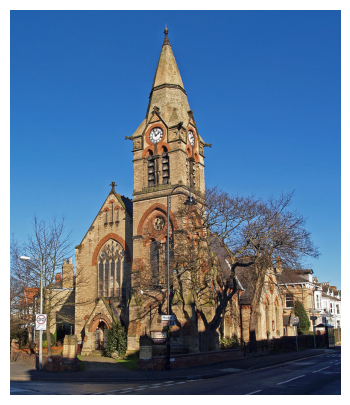

word_ids=tensor([[ 10, 119,  13,  83,  10, 247,   2,   2,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['a', 'white', 'cow', 'with', 'a', 'skateboard', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


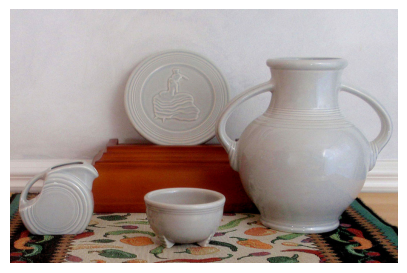

word_ids=tensor([[173, 155, 182,  10, 350,  23,  10, 111,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['other', 'food', 'by', 'a', 'tennis', 'on', 'a', 'table', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


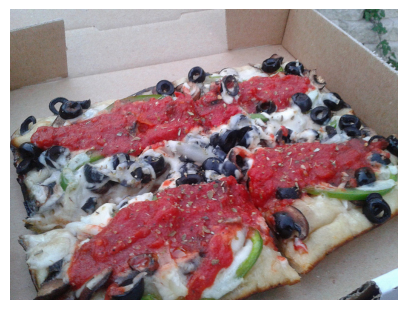

word_ids=tensor([[ 50,  23,  10, 167,  83,  10, 247,   2,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['people', 'on', 'a', 'dog', 'with', 'a', 'skateboard', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


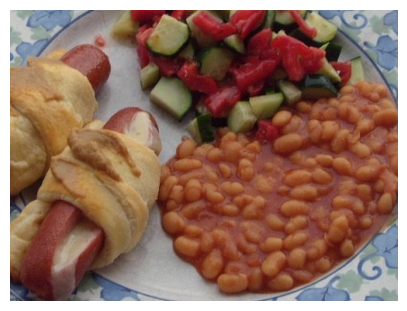

word_ids=tensor([[381, 425, 614,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['players', 'soccer', 'sink', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


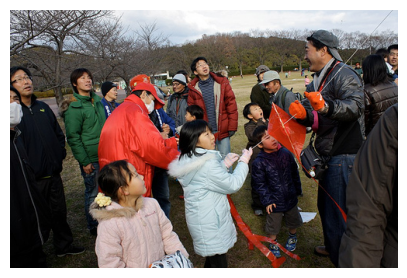

word_ids=tensor([[281,  83, 319, 172,  23,  10, 247,   2,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['protestors', 'with', 'truck', 'sitting', 'on', 'a', 'skateboard', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


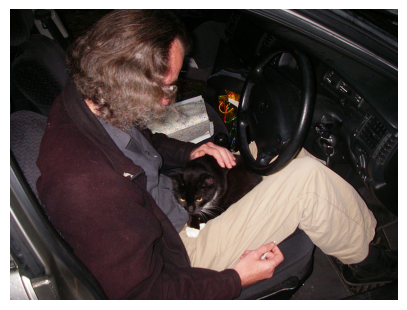

word_ids=tensor([[288,  85,  48, 179,  83,  10, 247,   2,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['young', 'man', 'is', 'playing', 'with', 'a', 'skateboard', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


In [28]:
for i in range(10):
    show_and_tell(frame.iloc[i]['img_name'], encoder=encoder, decoder=decoder)

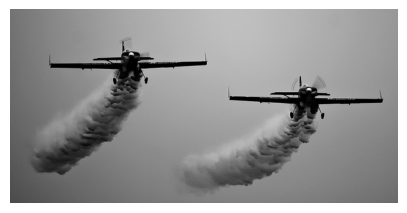

word_ids=tensor([[861, 811,  60,   6,  10,  32,   2,   2,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['scout', 'uniforms', ',', 'and', 'a', 'field', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


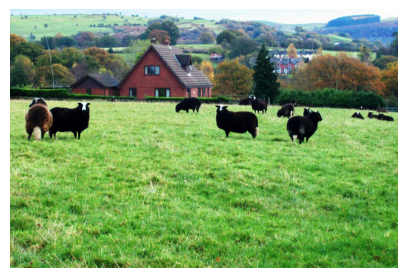

word_ids=tensor([[260, 539, 426, 839, 243, 244, 205,   2,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['boy', 'lined', 'match', 'steep', 'yellow', 'containers', 'out', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


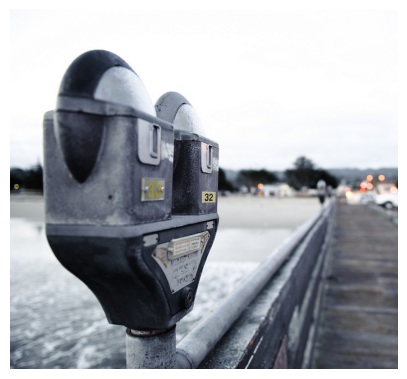

word_ids=tensor([[ 34,  70,  52,  10, 138, 910,   2,   2,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['bear', 'going', 'down', 'a', 'black', 'cows', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


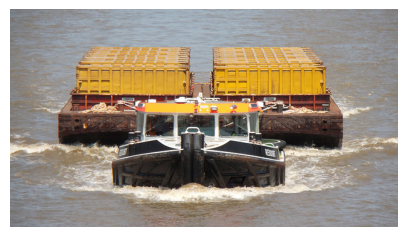

word_ids=tensor([[568,  10, 573,  55,  56,   2,   2,   2,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['dunking', 'a', 'mitt', 'covered', 'slope', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


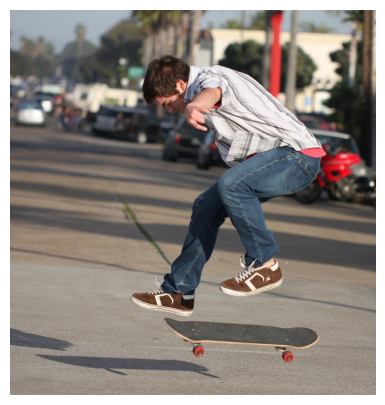

word_ids=tensor([[ 10, 122, 109,  48, 172,  23,  10, 247,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['a', 'plate', 'that', 'is', 'sitting', 'on', 'a', 'skateboard', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


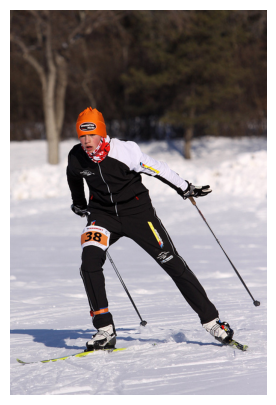

word_ids=tensor([[358, 778,  50, 178,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['player', 'umbrella', 'people', 'kites', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


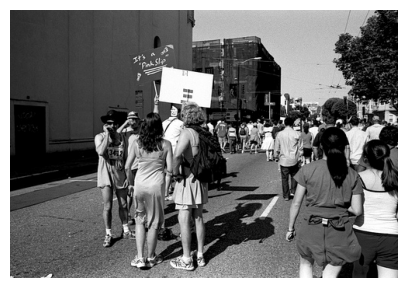

word_ids=tensor([[ 10, 539, 153,  35,  10, 119,  13,  83,  10, 247,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['a', 'lined', 'up', 'of', 'a', 'white', 'cow', 'with', 'a', 'skateboard', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


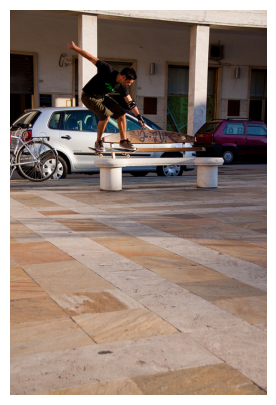

word_ids=tensor([[ 10, 166, 452, 172,  23,  10, 247,   2,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['a', 'small', 'suitcase', 'sitting', 'on', 'a', 'skateboard', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


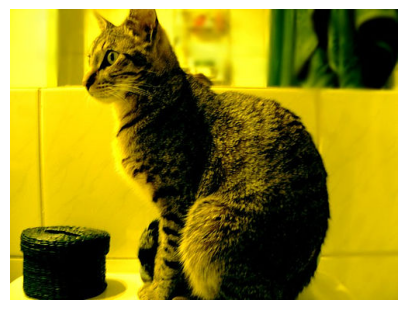

word_ids=tensor([[  4,  50,  23,  10, 167,  83,  10, 247,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['two', 'people', 'on', 'a', 'dog', 'with', 'a', 'skateboard', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


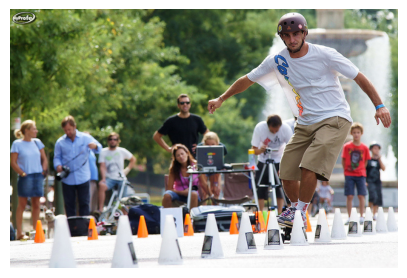

word_ids=tensor([[381,  21,  22,   6,  10,  88,   2,   2,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['players', 'are', 'standing', 'and', 'a', 'building', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


In [29]:
for i in range(10, 20):
    show_and_tell(frame.iloc[i]['img_name'], encoder=encoder, decoder=decoder)

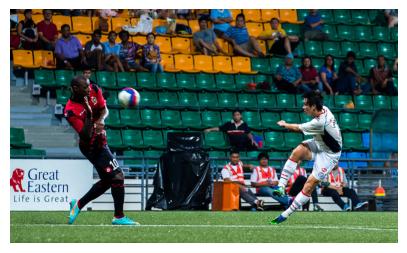

word_ids=tensor([[381, 910, 172,  23,  10, 247,   2,   2,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['players', 'cows', 'sitting', 'on', 'a', 'skateboard', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


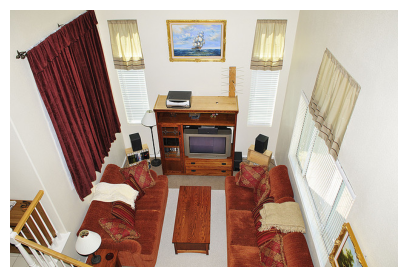

word_ids=tensor([[815, 442, 566,  10, 167,   2,   2,   6, 173, 155,  23,  10, 119, 196,
          35,  10, 166, 452, 172,  23,  10, 247,   2,   2,   2,   2,   6]]) 

['uniformed', 'shows', 'into', 'a', 'dog', '<END>', '<END>', 'and', 'other', 'food', 'on', 'a', 'white', 'photo', 'of', 'a', 'small', 'suitcase', 'sitting', 'on', 'a', 'skateboard', '<END>', '<END>', '<END>', '<END>', 'and']


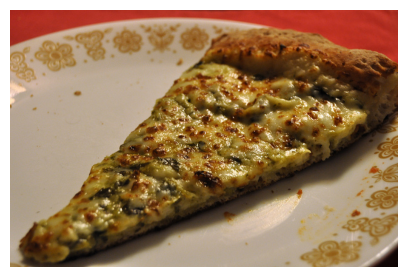

word_ids=tensor([[ 10, 167,  23,  10, 119,  13,   6,  10, 167,   2,   2,   2,   6, 173,
         155,  23,  10, 119, 196,  35,  10, 166, 452, 172,  23,  10, 247]]) 

['a', 'dog', 'on', 'a', 'white', 'cow', 'and', 'a', 'dog', '<END>', '<END>', '<END>', 'and', 'other', 'food', 'on', 'a', 'white', 'photo', 'of', 'a', 'small', 'suitcase', 'sitting', 'on', 'a', 'skateboard']


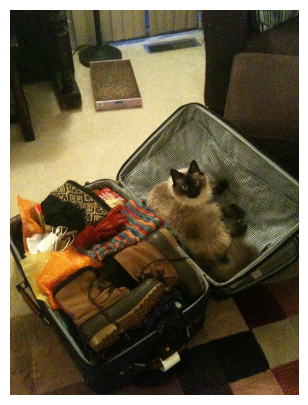

word_ids=tensor([[ 10, 166, 452, 172,  23,  10, 247,   2,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['a', 'small', 'suitcase', 'sitting', 'on', 'a', 'skateboard', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


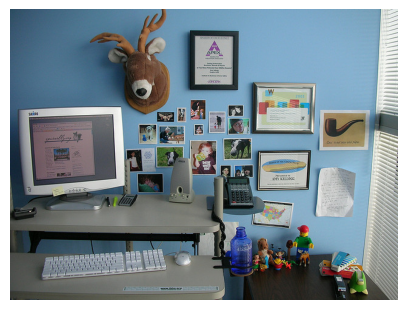

word_ids=tensor([[711, 624, 116, 117, 466, 230, 148,   2,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['boards', 'barred', 'fiesta', 'ware', 'head', 'meter', 'box', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


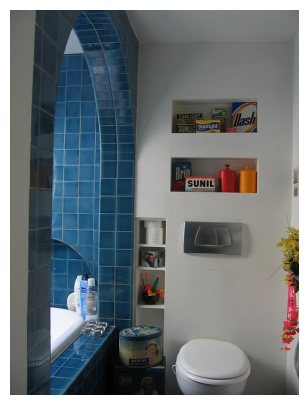

word_ids=tensor([[ 35, 212,  21,   9,  10, 461,   2,   2,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['of', 'sheep', 'are', 'in', 'a', 'desk', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


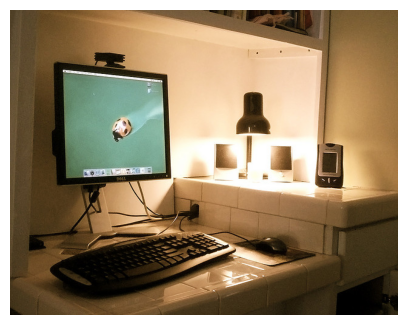

word_ids=tensor([[601, 205, 336, 351,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['bus', 'out', 'machine', 'ball', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


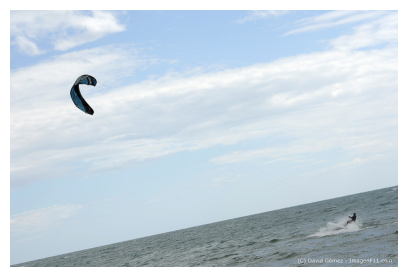

word_ids=tensor([[577,   6,  10, 119, 254,   2,   6, 173, 155,  23,  10, 119, 196,  35,
          10, 166, 452, 172,  23,  10, 247,   2,   2,   2,   2,   6, 173]]) 

['elephant', 'and', 'a', 'white', 'shirt', '<END>', 'and', 'other', 'food', 'on', 'a', 'white', 'photo', 'of', 'a', 'small', 'suitcase', 'sitting', 'on', 'a', 'skateboard', '<END>', '<END>', '<END>', '<END>', 'and', 'other']


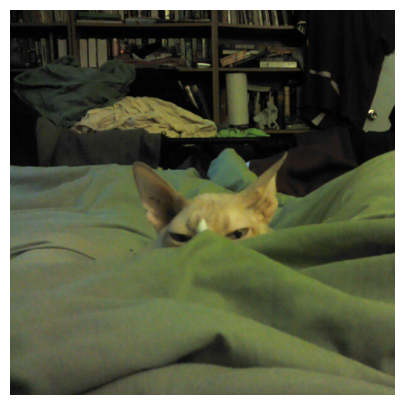

word_ids=tensor([[ 10, 166, 452, 172,  23,  10, 247,   2,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['a', 'small', 'suitcase', 'sitting', 'on', 'a', 'skateboard', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


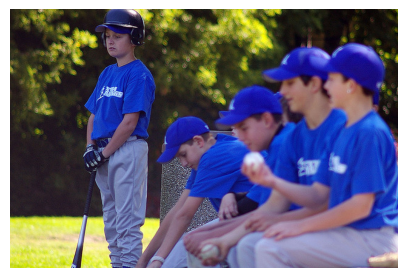

word_ids=tensor([[288,  50,  22,   9,  10, 167,   2,   2,   2,   2,   2,   2,   2,   2,
           2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2]]) 

['young', 'people', 'standing', 'in', 'a', 'dog', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>', '<END>']


In [30]:
for i in range(30, 40):
    show_and_tell(frame.iloc[i]['img_name'], encoder=encoder, decoder=decoder)